In [1]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart (1).csv


In [3]:
!pip install plotly

In [4]:
import plotly.express as px
import plotly.graph_objects as go

Saving heart.csv to heart (5).csv
First 5 Rows
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  102

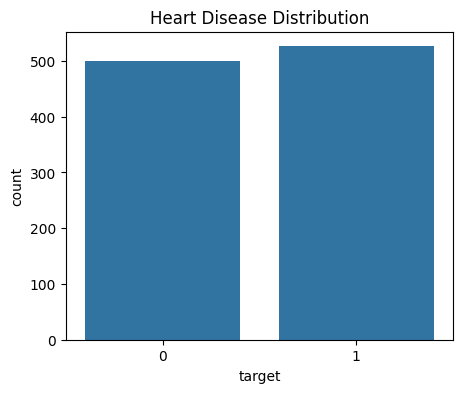

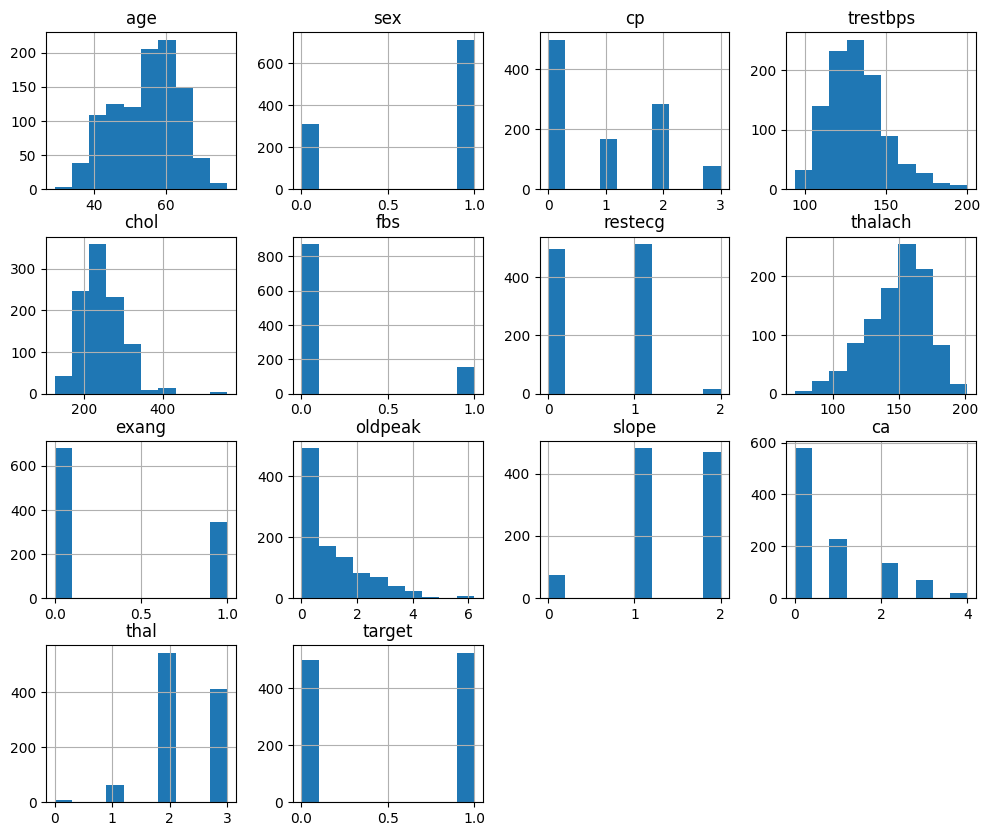

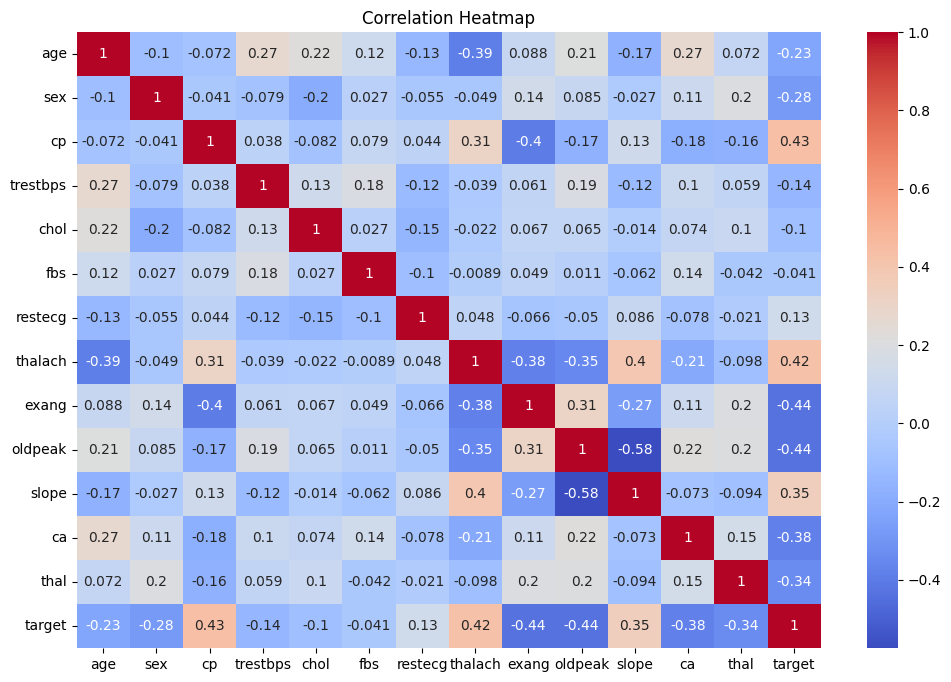


LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205

ROC AUC: 0.7947363411383972

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

ROC AUC: 0.9854368932038835

XGBOOST
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99    

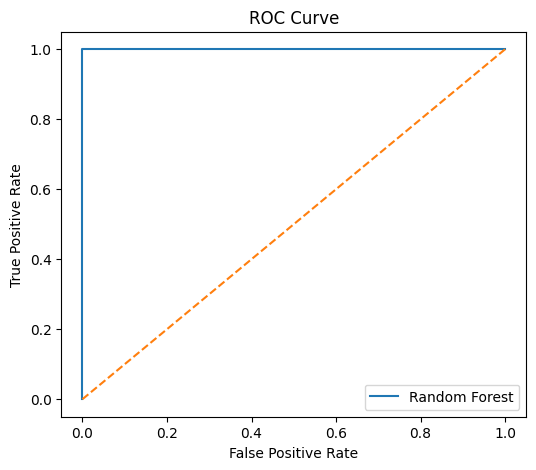

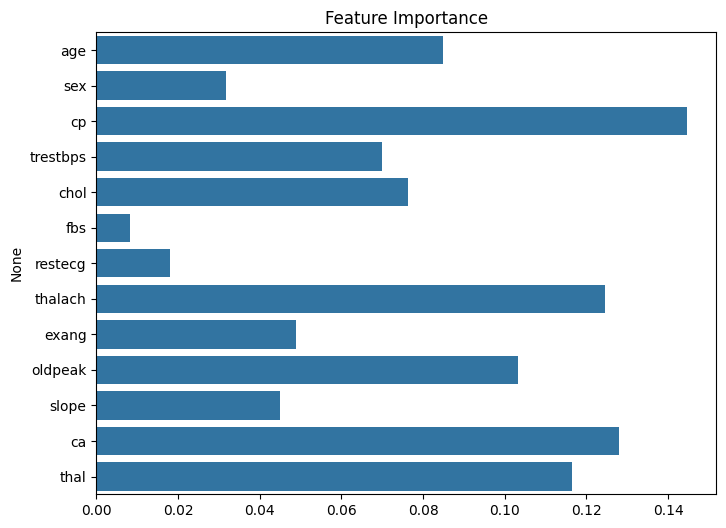

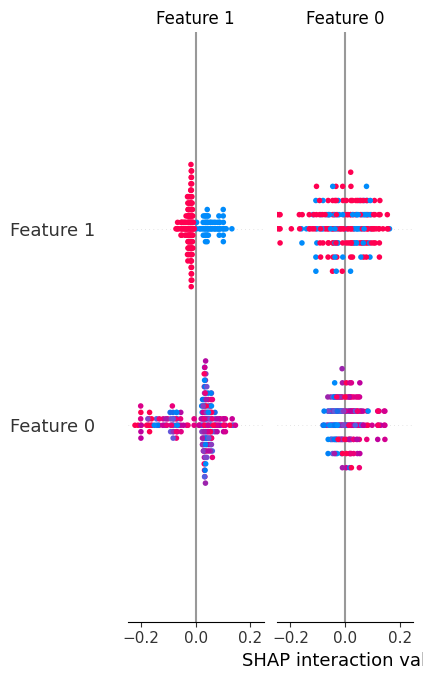


Enter Patient Details
Age: 50
Sex (1=Male,0=Female): 0
Chest Pain Type (0-3): 2
Resting Blood Pressure: 130
Cholesterol: 250
Fasting Blood Sugar (1=True,0=False): 1
Rest ECG (0-2): 1
Max Heart Rate: 150
Exercise Angina (1=Yes,0=No): 1
Oldpeak: 1.5
Slope (0-2): 1
Major Vessels (0-3): 2
Thal (0-3): 2

⚠ Patient has risk of Heart Disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



In [7]:
# ============================================
# HEART DISEASE PREDICTION WITH DASHBOARD
# ============================================

# Install libraries
!pip install xgboost shap plotly

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import shap

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# ============================================
# DATASET UPLOAD
# ============================================

uploaded = files.upload()

df = pd.read_csv("heart.csv")

print("First 5 Rows")
print(df.head())


# ============================================
# DATASET INFORMATION
# ============================================

print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())


# ============================================
# EDA VISUALIZATION
# ============================================

plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()


df.hist(figsize=(12,10))
plt.show()


plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


# ============================================
# DASHBOARD (INTERACTIVE PLOTS)
# ============================================

fig = px.pie(df,
             names="target",
             title="Heart Disease Distribution Dashboard")
fig.show()


fig = px.histogram(df,
                   x="age",
                   color="target",
                   title="Age vs Heart Disease",
                   barmode="overlay")
fig.show()


fig = px.box(df,
             x="target",
             y="chol",
             title="Cholesterol vs Heart Disease")
fig.show()


fig = px.scatter(df,
                 x="age",
                 y="thalach",
                 color="target",
                 title="Age vs Max Heart Rate")
fig.show()


fig = px.imshow(df.corr(),
                text_auto=True,
                title="Feature Correlation Dashboard")
fig.show()


# ============================================
# DATA PREPROCESSING
# ============================================

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ============================================
# LOGISTIC REGRESSION
# ============================================

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("\nLOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_pred_log))


# ============================================
# RANDOM FOREST
# ============================================

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\nRANDOM FOREST")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_pred_rf))


# ============================================
# XGBOOST
# ============================================

xgb_model = XGBClassifier()

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBOOST")
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_pred_xgb))


# ============================================
# ROC CURVE
# ============================================

y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


# ============================================
# FEATURE IMPORTANCE
# ============================================

importances = rf_model.feature_importances_

feature_names = X.columns

plt.figure(figsize=(8,6))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance")
plt.show()


# ============================================
# SHAP EXPLAINABILITY
# ============================================

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


# ============================================
# PATIENT INPUT PREDICTION SYSTEM
# ============================================

print("\nEnter Patient Details")

age = float(input("Age: "))
sex = float(input("Sex (1=Male,0=Female): "))
cp = float(input("Chest Pain Type (0-3): "))
trestbps = float(input("Resting Blood Pressure: "))
chol = float(input("Cholesterol: "))
fbs = float(input("Fasting Blood Sugar (1=True,0=False): "))
restecg = float(input("Rest ECG (0-2): "))
thalach = float(input("Max Heart Rate: "))
exang = float(input("Exercise Angina (1=Yes,0=No): "))
oldpeak = float(input("Oldpeak: "))
slope = float(input("Slope (0-2): "))
ca = float(input("Major Vessels (0-3): "))
thal = float(input("Thal (0-3): "))

patient_data = np.array([[age,sex,cp,trestbps,chol,fbs,restecg,thalach,
                          exang,oldpeak,slope,ca,thal]])

patient_data = scaler.transform(patient_data)

prediction = rf_model.predict(patient_data)

if prediction[0] == 1:
    print("\n⚠ Patient has risk of Heart Disease")
else:
    print("\n✅ Patient is Normal (No Heart Disease)")